<a href="https://colab.research.google.com/github/natee-s/Data_storytelling_fire_stat/blob/main/THackle_Data_storytelling_fire_stat_2562_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🎓 Storytelling with Data: สถิติการเกิดอัคคีภัยในประเทศไทย ปีพ.ศ. 2562
-------------------------------------
📦 ข้อมูล: ชุดข้อมูลนี้เป็นข้อมูลสถิติอัคคีภัยของประเทศไทย ประจำปี พ.ศ. 2562 จัดเก็บในระดับ รายจังหวัด ครอบคลุมข้อมูลจำนวนเหตุการณ์อัคคีภัย ความสูญเสียต่อชีวิต ทรัพย์สิน โครงสร้างพื้นฐาน และผลกระทบต่อชุมชนและพื้นที่ทางการเกษตร โดยมีวัตถุประสงค์เพื่อใช้ในการวิเคราะห์สถานการณ์อัคคีภัย การประเมินความเสี่ยง และการสนับสนุนการวางแผนนโยบายด้านการป้องกันและบรรเทาสาธารณภัย

ข้อมูลของ กรมป้องกันและบรรเทาสาธารณภัย

จาก https://envilink.go.th/dataset/dpm-gd026

Link Dataset:https://www.thackle.or.th/th/dataset/26

| ขั้นตอน | หัวข้อ |
|--------|--------|
| ⁉ | CSV File Pre-Screening |
| 1️⃣ | Setup & Load Data |
| 2️⃣ | Data Cleaning |
| 3️⃣ | Exploratory Data Analysis (EDA) |
| 4️⃣ | สรุปคำตอบโจทย์ทั้ง 3 ข้อ |
| 5️⃣ | การสร้าง Executive Dashboard |


### ⁉ CSV File Pre-Screening
 สิ่งที่พบ :
 1. มี Header 2 บรรทัด
 2. มีบรรทัดว่าง 2 บรรทัด
 3. มี Footer ที่เป็นประโยค


### 1️⃣ Setup & Load Data

In [ ]:
# ติดตั้ง library ที่จำเป็น
!pip install plotly kaleido --quiet
!pip install pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

import seaborn as sns
import matplotlib.pyplot as plt

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# โหลดข้อมูลโดยข้ามแถวที่ 1 (ภาษาไทย) เพื่อให้หัวตารางเป็นภาษาอังกฤษที่เขียนโค้ดง่าย
df = pd.read_csv('gd026_fire_stat2562_final.csv', skiprows=[1])
#ตรวจสอบข้อมูล 5 แถวแรก
display(df.head())


,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
0,กระบี่,3,2.0,5.0,7,-,-,4,4,-,...,-,-,-,-,-,-,-,1,-,-
1,กาญจนบุรี,7,7.0,7.0,5,-,-,64,38,-,...,-,-,-,-,-,-,-,-,-,"6,738,000"
2,กาฬสินธุ์,40,14.0,30.0,40,1,1,182,55,1,...,-,-,1,-,10,1,-,-,2,"12,973,690"
3,ขอนแก่น,28,13.0,25.0,30,-,-,95,32,-,...,-,-,-,-,-,-,-,3,2,"6,243,886"
4,จันทบุรี,1,1.0,1.0,-,-,-,-,-,-,...,-,-,-,-,-,-,-,1,-,-


In [ ]:
#ตรวจสอบประเภทของข้อมูล (Data Types)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   province                69 non-null     object 
 1   event_count             66 non-null     object 
 2   district                66 non-null     float64
 3   subdistrict_count       66 non-null     float64
 4   village_count           66 non-null     object 
 5   local_admin_count       66 non-null     object 
 6   community_count         66 non-null     object 
 7   population              66 non-null     object 
 8   households              66 non-null     object 
 9   fatalities_count        66 non-null     object 
 10  injuries_count          66 non-null     object 
 11  firefighter_injuries    66 non-null     object 
 12  firefighter_fatalities  66 non-null     object 
 13  total_home_loss         66 non-null     object 
 14  partial_home_loss       66 non-null     obje

###2️⃣ Data Cleaning
------------------------------------
Target:

1. เปลี่ยน - ให้กลายเป็น 0

2. ลบเครื่องหมายคอมมา , ออกจากตัวเลข

3. แปลงประเภทข้อมูล (Data Type) จาก object ให้เป็น float หรือ int เพื่อใช้บวกลบคูณหารได้

4. เอาแถวที่ไม่เกี่ยวข้องออก

### ✂คัดกรอง "แถว" ที่ไม่เกี่ยวข้องออก (Row Filtering)

In [ ]:
# สร้างสำเนาเพื่อไม่ให้กระทบข้อมูลต้นฉบับ
df_clean = df.copy()

# ลบแถวที่เป็นข้อความอ้างอิง
# เราจะใช้คำสั่ง .str.contains เพื่อดักจับคำสำคัญ (Keywords)
# สัญลักษณ์ ~ (Tilde) ข้างหน้าหมายถึง "ไม่เอา"
keywords_to_remove = ['ข้อมูล ณ วันที่', 'กรมป้องกัน', 'ศูนย์อำนวยการ', 'ทั้งหมด']

#.astype(str): คือการบังคับให้ข้อมูลในคอลัมน์ province เป็น "ข้อความ" ก่อน (เพื่อป้องกัน Error หากบางแถวเป็นตัวเลขหรือค่าว่าง)
for word in keywords_to_remove:
  df_clean = df_clean[~df_clean['province'].astype(str).str.contains(word)]

# ลบช่องว่างที่อาจติดมาในชื่อจังหวัด
df_clean['province'] = df_clean['province'].str.strip()

display(df_clean)


,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
0,กระบี่,3,2.0,5.0,7,-,-,4,4,-,...,-,-,-,-,-,-,-,1,-,-
1,กาญจนบุรี,7,7.0,7.0,5,-,-,64,38,-,...,-,-,-,-,-,-,-,-,-,"6,738,000"
2,กาฬสินธุ์,40,14.0,30.0,40,1,1,182,55,1,...,-,-,1,-,10,1,-,-,2,"12,973,690"
3,ขอนแก่น,28,13.0,25.0,30,-,-,95,32,-,...,-,-,-,-,-,-,-,3,2,"6,243,886"
4,จันทบุรี,1,1.0,1.0,-,-,-,-,-,-,...,-,-,-,-,-,-,-,1,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,เพชรบูรณ์,1,1.0,1.0,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
63,เลย,15,5.0,5.0,4,9,9,25,8,-,...,-,-,-,-,1,-,-,-,-,"363,000"
64,แพร่,7,4.0,5.0,6,1,1,21,9,-,...,1,-,-,-,-,-,-,-,-,"700,000"
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###✂จัดการ "คอลัมน์" และประเภทข้อมูล (Data Type Conversion)

In [ ]:
# เลือกทุกคอลัมน์ยกเว้นคอลัมน์แรก (province) เพื่อแปลงเป็นตัวเลข
cols_to_fix = df_clean.columns[1:]

for col in cols_to_fix:
  # 1. ลบลูกน้ำ (,) ออก
  # 2. เปลี่ยนเครื่องหมายขีด (-) ให้เป็นเลข 0 โดยใช้ .str.replace เพื่อแทนที่ในสตริง
  # 3. ตัดช่องว่างที่อาจปนมา
  cleaned_values = df_clean[col].astype(str).str.replace(',', '').str.replace('-', '0').str.strip()
  # แปลง Object เป็นตัวเลข Numeric โดยให้ค่าที่แปลงไม่ได้เป็น NaN
  df_clean[col] = pd.to_numeric(cleaned_values, errors='coerce')

# ตรวจสอบข้อมูล
display(df_clean)

,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
0,กระบี่,3.0,2.0,5.0,7.0,0.0,0.0,4.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,กาญจนบุรี,7.0,7.0,7.0,5.0,0.0,0.0,64.0,38.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6738000.0
2,กาฬสินธุ์,40.0,14.0,30.0,40.0,1.0,1.0,182.0,55.0,1.0,...,0.0,0.0,1.0,0.0,10.0,1.0,0.0,0.0,2.0,12973690.0
3,ขอนแก่น,28.0,13.0,25.0,30.0,0.0,0.0,95.0,32.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,6243886.0
4,จันทบุรี,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,เพชรบูรณ์,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63,เลย,15.0,5.0,5.0,4.0,9.0,9.0,25.0,8.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,363000.0
64,แพร่,7.0,4.0,5.0,6.0,1.0,1.0,21.0,9.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700000.0
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### เก็บตกความเรียบร้อย

In [ ]:
# เติมค่าว่างด้วย 0
df_clean = df_clean.fillna(0)

# ลบแถวที่ชื่อจังหวัดเป็น 0 หรือว่าง
df_clean = df_clean[df_clean['province'] != 0]

#ตรวจสอบ
print(f"มีจำนวนข้อมูลทั้งหมด {len(df_clean)} จังหวัด")
display(df_clean)

มีจำนวนข้อมูลทั้งหมด 65 จังหวัด


,province,event_count,district,subdistrict_count,village_count,local_admin_count,community_count,population,households,fatalities_count,...,shops,buildings,temporary_shelter,landfill_area,vehicles,religious_buildings,schools,government_offices,others,property_damage_cost
0,กระบี่,3.0,2.0,5.0,7.0,0.0,0.0,4.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,กาญจนบุรี,7.0,7.0,7.0,5.0,0.0,0.0,64.0,38.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6738000.0
2,กาฬสินธุ์,40.0,14.0,30.0,40.0,1.0,1.0,182.0,55.0,1.0,...,0.0,0.0,1.0,0.0,10.0,1.0,0.0,0.0,2.0,12973690.0
3,ขอนแก่น,28.0,13.0,25.0,30.0,0.0,0.0,95.0,32.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,6243886.0
4,จันทบุรี,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,เชียงใหม่,6.0,5.0,7.0,5.0,0.0,0.0,0.0,1.0,3.0,...,3.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
61,เพชรบุรี,18.0,4.0,6.0,8.0,9.0,9.0,39.0,11.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,733000.0
62,เพชรบูรณ์,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63,เลย,15.0,5.0,5.0,4.0,9.0,9.0,25.0,8.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,363000.0


### 🔖จัดกลุ่มภูมิภาค
โดยเราต้องมีการสร้าง columns ใหม่ เพื่อจัดเก็บข้อมูลภูมิภาค

In [ ]:
# กำหนดรายชื่อจังหวัดในแต่ละภาค (สร้างเป็น Dictionary)
region_mapping = {
    'ภาคเหนือ': ['เชียงราย', 'เชียงใหม่', 'น่าน', 'พะเยา', 'แพร่', 'แม่ฮ่องสอน', 'ลำปาง', 'ลำพูน', 'อุตรดิตถ์'],
    'ภาคตะวันออกเฉียงเหนือ': ['กาฬสินธุ์', 'ขอนแก่น', 'ชัยภูมิ', 'นครพนม', 'นครราชสีมา', 'บึงกาฬ', 'บุรีรัมย์', 'มหาสารคาม', 'มุกดาหาร', 'ยโสธร', 'ร้อยเอ็ด', 'เลย', 'ศรีสะเกษ', 'สกลนคร', 'สุรินทร์', 'หนองคาย', 'หนองบัวลำภู', 'อำนาจเจริญ', 'อุดรธานี', 'อุบลราชธานี'],
    'ภาคกลาง': ['กรุงเทพมหานคร', 'กำแพงเพชร', 'ชัยนาท', 'นครนายก', 'นครปฐม', 'นครสวรรค์', 'นนทบุรี', 'ปทุมธานี', 'พระนครศรีอยุธยา', 'พิจิตร', 'พิษณุโลก', 'เพชรบูรณ์', 'ลพบุรี', 'สมุทรปราการ', 'สมุทรสงคราม', 'สมุทรสาคร', 'สระบุรี', 'สิงห์บุรี', 'สุโขทัย', 'สุพรรณบุรี', 'อ่างทอง', 'อุทัยธานี'],
    'ภาคตะวันออก': ['จันทบุรี', 'ฉะเชิงเทรา', 'ชลบุรี', 'ตราด', 'ปราจีนบุรี', 'ระยอง', 'สระแก้ว'],
    'ภาคตะวันตก': ['กาญจนบุรี', 'ตาก', 'ประจวบคีรีขันธ์', 'เพชรบุรี', 'ราชบุรี'],
    'ภาคใต้': ['กระบี่', 'ชุมพร', 'ตรัง', 'นครศรีธรรมราช', 'นราธิวาส', 'ปัตตานี', 'พังงา', 'พัทลุง', 'ภูเก็ต', 'ระนอง', 'สตูล', 'สงขลา', 'สุราษฎร์ธานี', 'ยะลา']
}

# สร้าง function for mapping data
# Function นี้จะรับชื่อจังหวัดเข้าไป แล้ว output เป็น "ภาค" ออกมา
def assign_region(province):
    for region, provinces in region_mapping.items():
        if province in provinces:
            return region
    return 'ไม่ระบุ' # ถ้าหาไม่เจอให้ลงว่าไม่ระบุ

#create new column โดยใช้ function ที่เราสร้างขึ้น
df_clean['region'] = df_clean['province'].apply(assign_region)

# แสดงผลลัพธ์
print("--- จำนวนจังหวัดในแต่ละภูมิภาค ---")
print(df_clean['region'].value_counts())

# ตรวจสอบจังหวัดที่ "ไม่ระบุ" (ถ้ามี)
missing_provinces = df_clean[df_clean['region'] == 'ไม่ระบุ']['province'].unique()
if len(missing_provinces) > 0:
    print(f"\n⚠️ จังหวัดที่ยังจัดกลุ่มไม่ได้: {missing_provinces}")
else:
    print("\n✅ จัดกลุ่มครบถ้วนทุกจังหวัดแล้ว!")

print("--แสดงรายชื่อและภูมิภาค 10 แถวบนสุด--")
display(df_clean[['province', 'region']].head(10))

--- จำนวนจังหวัดในแต่ละภูมิภาค ---
region
ภาคตะวันออกเฉียงเหนือ    19
ภาคกลาง                  17
ภาคใต้                   10
ภาคเหนือ                  8
ภาคตะวันออก               6
ภาคตะวันตก                5
Name: count, dtype: int64

✅ จัดกลุ่มครบถ้วนทุกจังหวัดแล้ว!
--แสดงรายชื่อและภูมิภาค 10 แถวบนสุด--


,province,region
0,กระบี่,ภาคใต้
1,กาญจนบุรี,ภาคตะวันตก
2,กาฬสินธุ์,ภาคตะวันออกเฉียงเหนือ
3,ขอนแก่น,ภาคตะวันออกเฉียงเหนือ
4,จันทบุรี,ภาคตะวันออก
5,ฉะเชิงเทรา,ภาคตะวันออก
6,ชลบุรี,ภาคตะวันออก
7,ชัยนาท,ภาคกลาง
8,ชัยภูมิ,ภาคตะวันออกเฉียงเหนือ
9,ตรัง,ภาคใต้


### 3️⃣Exploratory Data Analysis (EDA)
------------------------------------
1. Check Vitals (สถิติพื้นฐาน): ดูค่าเฉลี่ยและค่าสูงสุดของประเทศ (ตาราง)

2. Find Extremes (จัดอันดับ): จังหวัดไหนคือที่สุดในแต่ละด้าน (กราฟแท่ง)

3. Correlation (หาความสัมพันธ์): เกิดบ่อยแล้วเสียหายเยอะจริงไหม? (กราฟ Scatter)

4. Regional Context (เปรียบเทียบภาค): ภูมิศาสตร์มีผลอย่างไร? (กราฟแท่งแยกกลุ่ม)

✅ Check Vitals (สถิติพื้นฐาน): ดูค่าเฉลี่ยและค่าสูงสุดของประเทศ (ตาราง)

In [ ]:
# 1. ดูค่าสถิติเชิงพรรณนา
# เราจะโฟกัสที่ 2 ตัวแปรหลัก คือ จำนวนครั้ง (event_count) และ มูลค่าความเสียหาย (property_damage_cost)
eda_summary = df_clean[['event_count', 'property_damage_cost']].describe()

print("--- สถิติภาพรวมระดับประเทศ ---")
display(eda_summary)

--- สถิติภาพรวมระดับประเทศ ---


,event_count,property_damage_cost
count,65.000000,6.500000e+01
mean,22.753846,7.343687e+06
std,22.036214,2.568971e+07
min,1.000000,0.000000e+00
25%,7.000000,0.000000e+00
50%,16.000000,2.500000e+05
75%,32.000000,2.425000e+06
max,119.000000,1.776300e+08


การวิเคราะห์:
- Mean: ค่าเฉลี่ยของประเทศเกิดอัคคีภัยอยู่ที่ 22.7 ครั้ง หากมีจังหวัดไหนสูงกว่านี้ คือ จะหมายถึงจังหวัดนั้นมีความเสี่ยงสูงกว่าปกติ

✅ Find Extremes (จัดอันดับ): จังหวัดไหนคือที่สุดในแต่ละด้าน (กราฟแท่ง)

In [ ]:
# เตรียมข้อมูล Top 10 จังหวัดที่เกิดเหตุบ่อยที่สุด
top_events = df_clean.nlargest(10,'event_count')

# สร้างกราฟแท่ง (Bar Chart)
fig_top_events = px.bar(
    top_events,
    x='province',
    y='event_count',
    title='Top 10 จังหวัดที่เกิดเหตุบ่อยที่สุด(ครั้ง)',
    color='event_count',
    color_continuous_scale='Reds',
    text_auto=True,
    labels={'province': 'จังหวัด', 'event_count': 'จำนวนเหตุการณ์'}
)
fig_top_events.show()

# เตรียมข้อมูล Top 10 จังหวัดที่มูลค่าความเสียหายสูงที่สุด
top_damage = df_clean.nlargest(10, 'property_damage_cost')

# สร้างกราฟแท่ง (Bar Chart)
fig_top_damage = px.bar(
    top_damage,
    x='province',
    y='property_damage_cost',
    title='Top 10 จังหวัดที่มูลค่าความเสียหายสูงที่สุด(บาท)',
    color='property_damage_cost',
    color_continuous_scale='Reds',
    text_auto='.2s',
    labels={'province': 'จังหวัด', 'property_damage_cost': 'มูลค่าความเสียหาย'}
)
fig_top_damage.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




✅ หาความสัมพันธ์ (Event vs. Damage)

In [ ]:
# สร้าง Scatter Plot เพื่อดูการกระจายตัว
fig_scatter = px.scatter(
    df_clean,
    x='event_count',
    y='property_damage_cost',
    hover_name='province', # ชี้แล้วเห็นชื่อจังหวัด
    size='property_damage_cost', # ขนาดของจุดมีขนาดตามมูลค่าความเสียหาย
    color='region', # แยกสีตามภาค
    title='ความสัมพันธ์: จำนวนครั้งที่เกิดเหตุ vs มูลค่าความเสียหาย (รายจังหวัด)',
    labels={'event_count': 'จำนวนเหตุการณ์', 'property_damage_cost': 'มูลค่าความเสียหาย(บาท)'}
)

#เพิ่มเส้นเฉลี่นเพื่อแบ่งโซนควาามเสี่ยง (Benchmark)
fig_scatter.add_hline(y=df_clean['property_damage_cost'].mean(), line_dash="dot", annotation_text="ค่าเฉลี่ยความเสียหาย")
fig_scatter.add_vline(x=df_clean['event_count'].mean(), line_dash="dot", annotation_text="ค่าเฉลี่ยจำนวนครั้ง")

fig_scatter.show()

####🔍 การวิเคราะห์ Insight:

โซนขวาบน: คือจังหวัดที่ "เสี่ยงจริง" (เกิดบ่อย + เสียหายหนัก)

โซนซ้ายบน: คือจังหวัดที่ "เกิดไม่บ่อย แต่ถ้าเกิดคือหายนะ" (เสียหายหนักมาก)

โซนขวาล่าง: คือจังหวัดที่ "เกิดบ่อยแต่คุมอยู่" (เสียหายต่อครั้งน้อย)

✅ Regional Context (เปรียบเทียบภาค): ภูมิศาสตร์มีผลอย่างไร? (กราฟแท่งแยกกลุ่ม)

In [ ]:
#รวมข้อมูลรายภาค
region_agg = df_clean.groupby('region')[['event_count', 'property_damage_cost']].mean().reset_index()

# สร้างกราฟเปรียบเทียบความเสียหายเฉลี่ยรายภาค
fig_region = px.bar(
    region_agg.sort_values('property_damage_cost', ascending=False),
    x='region',
    y='property_damage_cost',
    color='region',
    title='ค่าเฉลี่ยความเสียหายรายภูมิภาค',
    text_auto='.2s'
)
fig_region.show()

### 🔥 ข้อ 1 — จังหวัดไหนเสี่ยงจริง? (True Risk Profile)
------------------------------------
⚡ ใช้แนวคิด Risk Matrix
แบ่งกราฟออกเป็น 4 โซน ดังนี้ครับ:

**1. High Risk (ขวาบน)**: เกิดเหตุบ่อย + เสียหายหนัก (ต้องรีบจัดการด่วน!)

**2. Silent Threat (ซ้ายบน):** เกิดไม่บ่อย + แต่ถ้าเกิดคือพังพินาศ (ต้องเน้นมาตรการป้องกันอาคารขนาดใหญ่)

**3. Chronic Issues (ขวาล่าง):** เกิดเหตุบ่อย + แต่ความเสียหายต่ำ (อาจเป็นเหตุย่อยๆ บ่อยครั้ง ต้องเน้นการอบรมดับเพลิงเบื้องต้น)

**4. Low Risk (ซ้ายล่าง):** เกิดไม่บ่อย + เสียหายต่ำ (กลุ่มที่ค่อนข้างปลอดภัย)


In [ ]:
# คำนวณค่าเฉลี่ยเพื่อใช้เป็นเส้นแบ่ง (Threshold)
mean_events = df_clean['event_count'].mean()
mean_damage = df_clean['property_damage_cost'].mean()

# สร้างฟังก์ชันเพื่อแบ่งกลุ่ม (Labeling)
def categorize_risk(row):
    if row['event_count'] > mean_events and row['property_damage_cost'] > mean_damage:
        return ' High Risk (สูงทั้งคู่)'
    elif row['event_count'] <= mean_events and row['property_damage_cost'] > mean_damage:
        return ' Silent Threat (เสียหายหนักแต่เกิดน้อย)'
    elif row['event_count'] > mean_events and row['property_damage_cost'] <= mean_damage:
        return ' Chronic Issues (เกิดบ่อยแต่เสียหายไม่สูง)'
    else:
        return ' Low Risk (ความเสี่ยงต่ำ)'

# เพิ่มคอลัมน์ Risk_Level เข้าไปใน Data
df_clean['risk_level'] = df_clean.apply(categorize_risk, axis=1)

# สร้างกราฟ Risk Matrix
fig_risk = px.scatter(
    df_clean,
    x='event_count',
    y='property_damage_cost',
    color='risk_level',
    hover_name='province',
    size='property_damage_cost', # วงกลมใหญ่ตามความเสียหาย
    title='🎯 Fire Risk Matrix 2562: การแบ่งกลุ่มความเสี่ยงรายจังหวัด',
    labels={'event_count': 'จำนวนครั้งที่เกิดเหตุ', 'property_damage_cost': 'มูลค่าความเสียหาย (บาท)'},
    color_discrete_map={
        ' High Risk (สูงทั้งคู่)': '#EF553B',      # สีแดง
        ' Silent Threat (เสียหายหนักแต่เกิดน้อย)': '#FECB52', # สีส้ม/เหลือง
        ' Chronic Issues (เกิดบ่อยแต่เสียหายไม่สูง)': '#636EFA', # สีน้ำเงิน
        ' Low Risk (ความเสี่ยงต่ำ)': '#00CC96'      # สีเขียว
    }
)

# ใส่เส้นแบ่งค่าเฉลี่ย(Mean Lines)
fig_risk.add_hline(y=mean_damage, line_dash="dash", line_color="gray", annotation_text="ค่าเฉลี่ยความเสียหาย")
fig_risk.add_vline(x=mean_events, line_dash="dash", line_color="gray", annotation_text="ค่าเฉลี่ยจำนวนครั้ง")

fig_risk.show()

### 🎯 สรุปคำตอบโจทย์ข้อ 1: จังหวัดไหนเสี่ยงจริง? (True Risk Profile)
------------------------------------
จากการวิเคราะห์ข้อมูลอัคคีภัยปี 2562 โดยใช้เกณฑ์ค่าเฉลี่ยของประเทศ (จำนวนเหตุการณ์เฉลี่ย ~23 ครั้ง และมูลค่าความเสียหายเฉลี่ย ~7.3 ล้านบาท) เราสามารถแบ่งกลุ่มความเสี่ยงได้ดังนี้:

**1. 🚨 กลุ่ม High Risk (ลำดับความสำคัญสูงสุด)**
เป็นกลุ่มที่เกิดเหตุบ่อยและสร้างความเสียหายสูงอย่างมีนัยสำคัญ ประกอบด้วย 7 จังหวัด:

- **ชลบุรี (จุดวิกฤตที่สุด)**: มีมูลค่าความเสียหายสูงถึง 177 ล้านบาท ซึ่งสูงกว่าค่าเฉลี่ยของประเทศถึง 24 เท่า! *, นครปฐม, นนทบุรี, นครราชสีมา, อุบลราชธานี, กาฬสินธุ์, อ่างทอง

- Insight: จังหวัดเหล่านี้ควรได้รับการจัดสรรงบประมาณด้านอุปกรณ์ดับเพลิงที่ทันสมัย และเพิ่มจำนวนสถานีดับเพลิงในจุดยุทธศาสตร์ เพราะ "เกิดบ่อยและเสียหายหนัก"

**2. ⚠️ กลุ่ม Silent Threat (ภัยเงียบที่รุนแรง)**
- สิงห์บุรี: แม้จะเกิดเหตุไม่บ่อย (อยู่ในโซนซ้ายของกราฟ) แต่เมื่อเกิดแล้วสร้างความเสียหายสูงมาก (วงกลมขนาดใหญ่)

- Insight: สะท้อนว่าพื้นที่นี้อาจมีสถานประกอบการขนาดใหญ่ หรือโรงงานที่เก็บวัสดุไวไฟสูง มาตรการที่ควรใช้คือ "การตรวจความปลอดภัยอาคาร (Building Audit)" ที่เข้มงวดกว่าปกติ

**3. 🔄 กลุ่ม Chronic Issues (ปัญหาเรื้อรัง)**
- จังหวัดอย่าง ขอนแก่น, สมุทรปราการ, ปทุมธานี (และอีก 16 จังหวัด) ตกอยู่ในกลุ่มที่เกิดเหตุบ่อยกว่าค่าเฉลี่ย แต่ความเสียหายยังไม่สูงเท่ากลุ่มแรก

- Insight: ควรเน้นการ "อบรมดับเพลิงเบื้องต้น" ให้กับชุมชน เพื่อให้สามารถระงับเหตุได้ทันท่วงทีก่อนที่ความเสียหายจะขยายวงกว้าง

### 📍🏚️ โจทย์ข้อ 2 — ความเสียหายกระจุกตัวที่ไหน และหนักแค่ไหน? (Where & How Severe?)
-------------------------------------
เป้าหมาย: ระบุพื้นที่และประเภทอาคารที่ได้รับผลกระทบหนักที่สุด เพื่อให้เห็น "รูปแบบ" (Pattern) ความเสียหายของแต่ละภาค


#### 🛠️เตรียมข้อมูลประเภทสิ่งปลูกสร้าง
จัดกลุ่มคอลัมน์ประเภทอาคารให้ดูง่ายขึ้น โดยแบ่งเป็นหมวดหมู่หลักๆ เช่น ที่อยู่อาศัย, พาณิชย์/โรงงาน, และสถานที่ราชการ/ชุมชน

In [ ]:
#เลือกคอลัมน์ประเภทสิ่งปลูกสร้าง
building_cols = [
    'total_home_loss', 'partial_home_loss', 'commercial_buildings',
    'factories', 'shops', 'warehouses', 'government_offices', 'schools'
]

# รวมข้อมูลตามภูมิภาค (หาผลรวมของแต่ละประเภทอาคาร)
region_building_impact = df_clean.groupby('region')[building_cols].sum().reset_index()

# เตรียมข้อมูลมูลค่าความเสียหายรวมรายภาคด้วย
region_damage_total = df_clean.groupby('region')['property_damage_cost'].sum().reset_index()

# รวมข้อมูลทั้งสองส่วนเข้าด้วยกัน
q2_data = pd.merge(region_building_impact, region_damage_total, on='region')

display(q2_data)

,region,total_home_loss,partial_home_loss,commercial_buildings,factories,shops,warehouses,government_offices,schools,property_damage_cost
0,ภาคกลาง,164.0,175.0,11.0,16.0,41.0,6.0,0.0,6.0,185851314.0
1,ภาคตะวันตก,85.0,22.0,0.0,1.0,2.0,0.0,1.0,0.0,9896000.0
2,ภาคตะวันออก,26.0,53.0,0.0,11.0,11.0,6.0,2.0,0.0,179710360.0
3,ภาคตะวันออกเฉียงเหนือ,279.0,206.0,17.0,0.0,1.0,7.0,9.0,2.0,83522438.0
4,ภาคเหนือ,42.0,34.0,1.0,1.0,8.0,2.0,2.0,1.0,10302750.0
5,ภาคใต้,24.0,45.0,1.0,1.0,1.0,1.0,1.0,0.0,8056800.0


#### 🛠️สร้าง Visualization แบบ Treemap (3 มิติในกราฟเดียว)
Treemap คือกราฟที่ใช้ "พื้นที่" บอกขนาดความเสียหาย และใช้ "สี" หรือ "การจัดกลุ่ม" บอกภูมิภาคและจังหวัด

In [ ]:
# สร้าง Treemap เพื่อหา Hotspot ของความเสียหาย
fig_treemap = px.treemap(
    df_clean,
    path=['region', 'province'], # ลำดับชั้น: ภาค -> จังหวัด
    values='property_damage_cost', # ขนาดของกล่องตามมูลค่าความเสียหาย
    color='region', # แยกสีตามภาค
    title='แผนภูมิจุดวิกฤต (Hotspot): มูลค่าความเสียหายแยกตามภูมิภาคและจังหวัด',
    hover_data=['event_count'] # ให้โชว์จำนวนครั้งตอนเอาเมาส์ไปชี้ด้วย
)

fig_treemap.update_traces(textinfo="label+value")
fig_treemap.show()

#### 🛠️สร้าง Heatmap เพื่อดู "ประเภทอาคาร" ที่เสียหายหนักในแต่ละภาค
ดูจุดอ่อนของแต่ละภาคอยู่ที่อาคารประเภทไหน

In [ ]:
# เราต้องปรับรูปตาราง (Melt) เพื่อให้วาดกราฟ Heatmap ได้ง่ายขึ้น
melted_buildings = region_building_impact.melt(id_vars='region', var_name='Building_Type', value_name='Count')

fig_heatmap = px.density_heatmap(
    melted_buildings,
    x="Building_Type",
    y="region",
    z="Count",
    title="Heatmap: ประเภทสิ่งปลูกสร้างที่เสียหายสะสมในแต่ละภูมิภาค",
    labels={'Count': 'จำนวนที่เสียหาย', 'region': 'ภูมิภาค', 'Building_Type': 'ประเภทอาคาร'},
    color_continuous_scale='Reds',
    text_auto=True
)

fig_heatmap.show()

### 🎯 สรุปคำตอบโจทย์ข้อ 2: ความเสียหายกระจุกตัวที่ไหน และหนักแค่ไหน? (Where & How Severe?)
------------------------------------

สามารถสรุป "รูปแบบความเสียหาย (Damage Patterns)" แยกตามพื้นที่และประเภทอาคารได้ดังนี้ครับ:

**1. จุดวิกฤตเชิงพื้นที่ (Spatial Hotspot)**: * ภาคตะวันออก (โดยเฉพาะชลบุรี) คือจุดวิกฤตที่รุนแรงที่สุดในเชิง "มูลค่า" แม้จำนวนหลังที่เสียหายอาจไม่มากเท่าภาคอื่น แต่ค่าความเสียหายต่อครั้งสูงมาก

**2. ประเภทอาคารที่เป็นจุดอ่อนหลัก (Vulnerable Building Type)**:
บ้านเรือน (Residential) คือประเภทสิ่งปลูกสร้างที่เสียหายมากที่สุดในทุกภูมิภาค สะท้อนว่าอัคคีภัยในไทยส่งผลกระทบโดยตรงต่อ "ที่อยู่อาศัยของประชาชน" มากกว่าภาคธุรกิจ

**3. ความต่างเชิงภูมิภาค (Regional Characteristics)**:
- ภาคตะวันออกเฉียงเหนือ: เน้นความเสียหายแบบ "บ้านเสียหายทั้งหลัง" (Total Loss) ซึ่งอาจสัมพันธ์กับวัสดุก่อสร้าง (เช่น บ้านไม้) และความห่างไกลจากสถานีดับเพลิง

- ภาคกลาง: มีความโดดเด่นเรื่องความเสียหายใน "อาคารพาณิชย์และโรงงาน" เนื่องจากเป็นศูนย์กลางเศรษฐกิจ

- ภาคตะวันออก: มีความเสียหายแบบ "บ้านเสียหายบางส่วน" สูงผิดปกติ ซึ่งอาจหมายถึงการเกิดเหตุในพื้นที่หนาแน่นที่ระงับเหตุได้เร็วแต่ส่งผลกระทบเป็นวงกว้าง

### ⚠️📈 โจทย์ข้อ 3 — อะไรคือตัวชี้วัดความรุนแรง? (What predicts severity?)
-------------------------------------
**เป้าหมาย:** ค้นหาว่าปัจจัยใด (เช่น จำนวนประชากร, ประเภทอาคาร, หรือพื้นที่) ที่มีความสัมพันธ์ (Correlation) กับการเกิดความสูญเสียในระดับ "หายนะ" (เสียชีวิต/เสียหายหนัก) มากที่สุด เพื่อให้รัฐบาลวางระบบเตือนภัยได้ถูกจุด

**💡 แนวคิดการวิเคราะห์:**
เราจะใช้สถิติที่เรียกว่า "Correlation (ค่าสหสัมพันธ์)" มาดูว่าถ้าตัวแปร A เพิ่มขึ้น ตัวแปร B จะเพิ่มขึ้นตามไหม?

ค่าเข้าใกล้ 1: มีความสัมพันธ์กันสูงมาก (ถ้า A เกิด B มักจะเกิดตาม)

ค่าเข้าใกล้ 0: ไม่เกี่ยวข้องกันเลย

### 🛠️ สร้าง Correlation Heatmap และกราฟวิเคราะห์ปัจจัย

Correlation Matrix: ความสัมพันธ์ของปัจจัยกับความรุนแรง


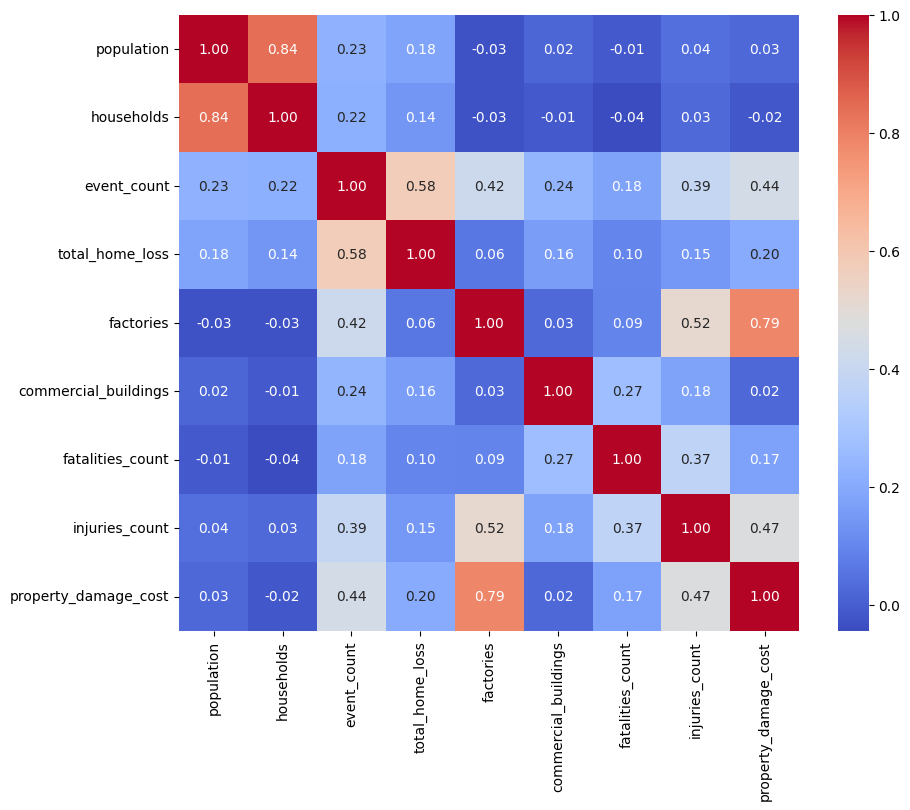

In [ ]:
# เลือกคอลัมน์ ที่อาจจะเป็นปัจจัยส่งผลต่อความรุนแรง
factors = [
    'population', 'households', 'event_count',
    'total_home_loss', 'factories', 'commercial_buildings',
    'fatalities_count', 'injuries_count', 'property_damage_cost'
]

# คำนวณค่าสหสัมพันธ์ (Correlation)
corr_matrix = df_clean[factors].corr()

# สร้างกราฟ Heatmap ด้วย Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
print("Correlation Matrix: ความสัมพันธ์ของปัจจัยกับความรุนแรง")
plt.show()

# สร้างกราฟ Scatter เพื่อดูความสัมพันธ์ระหว่าง "จำนวนประชากร" กับ "ความเสียหาย"
fig_pop_damage = px.scatter(
    df_clean,
    x='population',
    y='property_damage_cost',
    size='event_count', # Fixed the typo here from 'event_count' to 'event_count'
    color='region',
    hover_name='province',
    title='ความสัมพันธ์ระหว่างจำนวนประชากร และ มูลค่าความเสียหาย',
    labels={'population': 'จำนวนประชากร(คน)', 'property_damage_cost': 'มูลค่าความเสียหาย(บาท)'},
    trendline="ols" # เพิ่มเส้นแนวโน้มเพื่อดูทิศทาง
)
fig_pop_damage.show()

### ⚠️📈 สรุปคำตอบโจทย์ข้อ 3 — อะไรคือตัวชี้วัดความรุนแรง? (What predicts severity?)
------------------------------------

1. 🏭 โรงงาน คือ สิ่งที่สะท้อนถึงความเสียหายได้ดีที่สุด
**- ผลลัพธ์: **คอลัมน์ factories มีค่าความสัมพันธ์กับ property_damage_cost สูงถึง 0.79 (ซึ่งถือว่าสูงมากในทางสถิติ)

**- Insight สำหรับนโยบาย:** หากรัฐบาลต้องการลดตัวเลข "ความเสียหายทางเศรษฐกิจ" (มูลค่าทรัพย์สิน) มาตรการที่ได้ผลที่สุดไม่ใช่การกระจายรถดับเพลิงไปทุกที่ แต่คือการ **"เข้มงวดการตรวจมาตรฐานความปลอดภัยในโรงงานอุตสาหกรรม"** เพราะการเกิดเหตุในโรงงานเพียงครั้งเดียว อาจสร้างความเสียหายเท่ากับบ้านเรือนร้อยหลังรวมกัน

2. 👨‍👩‍👧‍👦 ประชากรเยอะ ไม่ได้แปลว่าคนจะตายเยอะ (The Density Paradox)
**- ผลลัพธ์:** จำนวนประชากร (population) มีค่าความสัมพันธ์กับจำนวนผู้เสียชีวิต (fatalities_count) ต่ำมาก (ใกล้เคียง 0)

**- Insight สำหรับนโยบาย**: เราไม่สามารถใช้แค่ "จำนวนคน" ในจังหวัดเป็นตัวตั้งในการเตรียมทีมกู้ชีพได้ เพราะความตายจากอัคคีภัยอาจสัมพันธ์กับปัจจัยอื่นที่ไม่ได้อยู่ในข้อมูลนี้ (เช่น ระยะเวลาที่รถดับเพลิงไปถึง หรือโครงสร้างบ้านที่เป็นวัสดุไวไฟในเขตเมืองเก่า หรือความพร้อมของอุปกรณ์ดับเพลิง)

3. 🚑 ความสูญเสียด้านทรัพย์สิน มักมาคู่กับ "การบาดเจ็บ"
**- ผลลัพธ์:** การบาดเจ็บ (injuries_count) มีความสัมพันธ์กับมูลค่าความเสียหายสูง (0.47)

**- Insight: **ในเหตุการณ์ที่ทรัพย์สินเสียหายหนัก มักจะมีผู้บาดเจ็บตามมาเสมอ (อาจเป็นเจ้าหน้าที่หรือผู้อยู่อาศัยที่พยายามปกป้องทรัพย์สิน)

## 📊 การสร้าง Executive Dashboard

In [ ]:
# 1. เตรียมข้อมูลสรุปรายภาค (สำหรับการแสดงผลที่รวดเร็ว)
reg_summary = df_clean.groupby('region')[['event_count', 'property_damage_cost']].sum().reset_index()

# 2. สร้าง Layout สำหรับ Dashboard (2 แถว 2 คอลัมน์)
fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=("1. Risk Matrix (การแบ่งกลุ่มจังหวัด)",
                    "2. Total Damage by Region (มูลค่าความเสียหาย)",
                    "3. Fire Events by Region (จำนวนครั้ง)",
                    "4. Top 5 Worst Provinces (จังหวัดที่เสียหายสูงสุด)"),
    vertical_spacing=0.15
)

# กราฟ 1: Risk Matrix (Scatter)
for level in df_clean['risk_level'].unique():
    subset = df_clean[df_clean['risk_level'] == level]
    fig_dash.add_trace(
        go.Scatter(x=subset['event_count'], y=subset['property_damage_cost'],
                   mode='markers', name=level, text=subset['province']),
        row=1, col=1
    )

# กราฟ 2: Damage by Region (Bar)
fig_dash.add_trace(
    go.Bar(x=reg_summary['region'], y=reg_summary['property_damage_cost'], name='ความเสียหาย'),
    row=1, col=2
)
# กราฟ 3: Events by Region (Bar)
fig_dash.add_trace(
    go.Bar(x=reg_summary['region'], y=reg_summary['event_count'], name='จำนวนครั้ง'),
    row=2, col=1
)

# กราฟ 4: Top 5 Provinces (Horizontal Bar)
top5 = df_clean.nlargest(5, 'property_damage_cost')
fig_dash.add_trace(
    go.Bar(x=top5['property_damage_cost'], y=top5['province'], orientation='h', name='Top 5 Damage'),
    row=2, col=2
)

# ปรับแต่งหน้าตา Dashboard
fig_dash.update_layout(height=800, title_text="📌 Fire Incident Dashboard 2562: สรุปวิเคราะห์สถานการณ์อัคคีภัย", showlegend=False)
fig_dash.show()

## ⛑Executive Summary

ข้อสรุป 3 ประเด็นหลัก

✴ 1. พื้นที่วิกฤต (Target Areas):

ชลบุรี คือจังหวัดที่ต้องได้รับความสำคัญอันดับหนึ่ง เนื่องจากมีค่าความเสียหายสูงกว่าค่าเฉลี่ยประเทศถึง 24 เท่า และตกอยู่ในกลุ่ม High Risk (สูงทั้งจำนวนครั้งและมูลค่า)

ภาคตะวันออกเฉียงเหนือ แม้มูลค่าจะไม่สูงที่สุด แต่มีอัตราการสูญเสียบ้านแบบ "เสียหายทั้งหลัง" สูงสุด ซึ่งกระทบต่อคุณภาพชีวิตประชาชนโดยตรง

✴ 2. ปัจจัยบ่งชี้ภัย (Key Predictors):

จำนวนโรงงาน (Factories) คือตัวแปรที่สัมพันธ์กับมูลค่าความเสียหายมากที่สุด (Corr = 0.79)

ข้อเสนอแนะ: ควรเปลี่ยนนโยบายจากการเฝ้าระวังตามจำนวนประชากร เป็นการ "เฝ้าระวังตามความหนาแน่นของโรงงานอุตสาหกรรม" แทน เพื่อลดมูลค่าความสูญเสียทางเศรษฐกิจ

✴ 3. จุดอ่อนที่ต้องแก้ไข (Vulnerabilities):

บ้านเรือน (Residential) คือสิ่งปลูกสร้างที่เสียหายบ่อยที่สุดในทุกภูมิภาค

ข้อเสนอแนะ: ควรมีการรณรงค์ติดตั้งเครื่องตรวจจับควัน (Smoke Detector) ในระดับครัวเรือน โดยเฉพาะในจังหวัดกลุ่ม Chronic Issues (เช่น ขอนแก่น, ปทุมธานี) ที่มีเหตุเกิดบ่อยครั้ง